# Harmonizing Kansas Local Government Surveys

This project combines the ARISE Kansas city survey and the CivicPulse survey to create a harmonized dataset for analyzing local government capacity, workforce challenges, and infrastructure stress.

The objective is to align overlapping constructs across datasets, document harmonization decisions, and conduct exploratory analysis using descriptive statistics, regression, and visualization.

In [102]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [103]:
#Load ARISE and CivicPulse datasets

arise = pd.read_csv("arise_dataset.csv")
civic = pd.read_csv("CivicPulse_KS.csv")

# Check dataset dimensions
print("Original ARISE shape:", arise.shape)
print("Original CivicPulse shape:", civic.shape)

display(arise.head())
display(civic.head())

Original ARISE shape: (309, 91)
Original CivicPulse shape: (135, 74)


,Unnamed: 0,ResponseId,RecipientLastName,ExternalReference,1st Dis,2nd Dis,3rd Dis,Q3_10_Agri,Q3_9_Cyber,Q3_19_Dam,Q3_1_Droughts,Q3_12_Earthquake,Q3_2_heat,Q3_3_Floods,Q3_4_Ice,Q3_7_waste spill,Q3_8_Industrial fire,Q3_22_Soil erosion,Q3_21_Severe storms,Q3_17_Terrorism,Q3_5_Tornados,Q3_11_Infrastructure failure,Q3_6_Wildfires,Q3_23_Others,Q3_23_TEXT,Q4_1,Q4_2,Q4_3,Q4_4,Q5,Q6_7_TEXT,Q7,Q8,Q12_1,Q12_2,Q12_3,Q12_4,Q12_5,Q12_6,Q12_7,Q119,Q29,Q30,Q31,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,Q6_6,Q6_7,Q9_Early warning,Q9_Evacuation plan,Q9_Financial assistance for low-income AC,Q9_Water conservation programs,Q9_Energy conservation programs,Q9_Zoning,Q9_Financial assistance for low-income shut-offs,Q9_Heating or cooling stations,Q9_Tornado shelter,Q9_Early warning_Lang,Q9_Code enforcement,Q9_Backup electric,Q9_Evacuation route or plan,Q9_None of the above,Q10_Elderly people,Q10_Low income,Q10_Homeless,Q10_Non-English,Q10_Racial minorities,Q10_Disabled,Q10_Immigrants,Q10_None of the above,Q11_Transportation,Q11_Electricity,Q11_Drinking water treatment,Q11_Wastewater treatment,Q11_Hospitals,Q11_Schools,"Q11_Cyber, IT",Q11_None of the above,Q13_Reduce staff,Q13_Defer capital projects,Q13_Reduce benefits,Q13_Reduce services,Q13_Increase taxes,Q13_Increase user fees,Q13_Adopt new fees,Q13_Reduce fund balance,Q13_Defer maintenance expenditures,Q13_None of the above
0,1,R_2sQNn7iItA9jdBn,chief administrator,2079950,3.0,21.0,1.0,NaN,NaN,NaN,3.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,3.0,3.0,NaN,3.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,6.0,1.0,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,1,1,0,1,1,1,0,0,0
1,2,R_2Qyp1YFLCR17M9C,chief administrator,2061250,11.0,3.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,5.0,4.0,5.0,4.0,2.0,NaN,3.0,4.0,1.0,4.0,1.0,4.0,2.0,2.0,1.0,4.0,3.0,5.0,1.0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,1,1,0,0,0,1,0
2,3,R_2aQAihYklmvMFey,chief administrator,2005600,11.0,21.0,1.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,4.0,1.0,3.0,2.0,3.0,NaN,4.0,5.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,4.0,6.0,6.0,1.0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,1,1,0,1,1,0,0,0,1,0
3,4,R_6sTVkGKJ3zy6aPL,chief administrator,2034300,21.0,1.0,2.0,NaN,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,2.0,NaN,3.0,3.0,1.0,1.0,1.0,4.0,1.0,3.0,2.0,3.0,3.0,6.0,1.0,0,0,1,1,0,0,0,1,0,0,1,1,1,1,1,1,0,1,1,0,0,1,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,5,R_3sddVtnZ4CSdNk0,chief administrator,2053225,3.0,1.0,23.0,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,Predecessor(s),3.0,3.0,5.0,3.0,3.0,NaN,4.0,3.0,3.0,3.0,4.0,4.0,4.0,5.0,2.0,3.0,4.0,6.0,1.0,0,1,1,1,0,0,0,1,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,0


,Respondentid,statecode,countycode,countysubcode,placecode,govname,state,stpl_fips,stco_fips,Roletype,Govtype,Stateabb,Workforce_SC,Challenges_MS,Challenges_MS_other_TEXT,Condition_SC,Infra_GR_spending,Infra_GR_relies,Infra_GR_budget,Infra_GR_competes,Asset_SC,Disaster_MS,Disaster_MS_other_TEXT,Planning_SC,Agencies_SC,Services_GR_early,Services_GR_backup,Services_GR_evac,Services_GR_financial,Services_GR_heating,Services_GR_public,Early_SC,Evacuation_SC,Water_MS,Water_MS_other_TEXT,Approach_GR_follow,Approach_GR_develop,Approach_GR_routine,Experiments_MS,Experiments_MS_other_TEXT,Leaders_MS,Leaders_MS_other_TEXT,Mode_MS,Mode_MS_other_TEXT,Minimize_MS,Impacts_MS,Impacts_MS_other_TEXT,Partner_SC,Groups_GR_elderly,Groups_GR_children,Groups_GR_homeless,Groups_GR_low,Groups_GR_non,Groups_GR_people,Groups_GR_undoc,Groups_LOE,Highest1_SC,Lowest1_SC,Highest2_SC,Lowest2_SC,Highest3_SC,Lowest3_SC,Disaster_LOE,Efficiency_GR_prov,Efficiency_GR_reduc,Efficiency_GR_worth,Efficiency_GR_maint,Efficiency_GR_resid,Efficiency_GR_people,Tenure_SC,Education_SC,Discipline_MS,Discipline_MS_other_TEXT,Party_SC
0,100203,20,107,.,56450,Pleasanton City,KS,2056450.0,20107.0,County/Municipal Policymaker,Municipality,KS,4.0,1,NaN,2.0,2.0,2.0,1.0,2.0,2.0,"1,2",NaN,2.0,2.0,1,1,5,5,1,1,2.0,NaN,"3,4",NaN,1.0,1.0,2.0,10,NaN,NaN,NaN,NaN,NaN,8,7,NaN,3.0,1.0,3.0,1.0,2.0,3.0,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,5.0,4.0,1.0,2.0,2.0,6.0,5,NaN,5.0
1,100799,20,173,.,44200,City Of Maize,KS,2044200.0,20173.0,County/Municipal Policymaker,Municipality,KS,4.0,2,NaN,3.0,3.0,3.0,5.0,4.0,4.0,5,Flooding affected some residents,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108545,20,173,.,73250,City Of Valley Center,KS,2073250.0,20173.0,County/Municipal Policymaker,Municipality,KS,2.0,1,NaN,4.0,2.0,3.0,2.0,2.0,4.0,"2,4",NaN,1.0,4.0,1,1,1,1,1,1,1.0,3.0,"1,2,3,4,5,6,7,8",NaN,4.0,4.0,4.0,"2,5,6,7,8",NaN,"1,2,3,4,5,6,7,8",NaN,"1,2,3,4,5,6,7",NaN,"2,3,5,6","2,3,4,5",NaN,1.0,3.0,5.0,3.0,3.0,4.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,111722,20,043,.,76000,Wathena City,KS,2076000.0,20043.0,County/Municipal Policymaker,Municipality,KS,4.0,"1,2",NaN,4.0,2.0,4.0,1.0,3.0,4.0,6,NaN,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,113753,20,091,.,19825,City Of Edgerton,KS,2019825.0,20091.0,County/Municipal Policymaker,Municipality,KS,1.0,NaN,NaN,5.0,5.0,4.0,4.0,2.0,4.0,2,NaN,2.0,1.0,3,1,3,"1,3,4",1,1,3.0,3.0,"3,4,5",NaN,4.0,3.0,2.0,10,NaN,NaN,NaN,NaN,NaN,2,2,NaN,2.0,4.0,4.0,1.0,3.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,1.0,2.0,5.0,3,NaN,6.0


## Data Cleaning

This step ensures consistency across datasets by handling missing values, standardizing formats, and removing invalid or incomplete observations.

In [104]:
#Clean column names and basic missing values
# Example: "Q3_7_waste spill" becomes "q3_7_waste_spill".

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return df


def basic_cleaning(df):
    df = df.copy()

    # Remove completely empty rows and columns
    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")

    # Convert common missing labels into NaN
    missing_labels = [
        "NA", "N/A", "na", "n/a", "", " ", "None", "none",
        "NULL", "null", "did not respond", "Don't know", "DK"
    ]
    df = df.replace(missing_labels, np.nan)

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Trim spaces from text columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace("nan", np.nan)

    return df


arise = basic_cleaning(clean_columns(arise))
civic = basic_cleaning(clean_columns(civic))

# Standardize respondent ID column name
arise = arise.rename(columns={"responseid": "id"})
civic = civic.rename(columns={"respondentid": "id"})

print("Cleaned ARISE shape:", arise.shape)
print("Cleaned CivicPulse shape:", civic.shape)

Cleaned ARISE shape: (309, 89)
Cleaned CivicPulse shape: (135, 68)


In [105]:
# Missing Value Summary (Dataset Level)
def missing_summary(df, dataset_name):
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    missing_pct = round((missing_cells / total_cells) * 100, 2)
    
 # Return results as a dictionar
    return {
        "Dataset": dataset_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Total Cells": total_cells,
        "Missing Cells": missing_cells,
        "Missing %": missing_pct
    }

missing_overview = pd.DataFrame([
    missing_summary(arise, "ARISE"),
    missing_summary(civic, "CivicPulse")
])

# Display clean summary table
display(missing_overview)

,Dataset,Rows,Columns,Total Cells,Missing Cells,Missing %
0,ARISE,309,89,27501,5533,20.12
1,CivicPulse,135,68,9180,3003,32.71


In [106]:
# Column-wise Missing Value Summary
def column_missing_summary(df, dataset_name):
    summary = pd.DataFrame({
        "Dataset": dataset_name,
        "Column": df.columns,
        "Total Values": df.shape[0],
        "Non-Missing Values": df.notnull().sum().values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": (df.isnull().mean().values * 100).round(2)
    })

    summary = summary.sort_values(by="Missing %", ascending=False)

# Display only top 15 columns (to avoid clutter)
    print(f"\nTop missing columns in {dataset_name}:")
    display(summary.head(15))

    return summary
    
# Run for both datasets
arise_summary = column_missing_summary(arise, "ARISE")
civic_summary = column_missing_summary(civic, "CivicPulse")


Top missing columns in ARISE:


,Dataset,Column,Total Values,Non-Missing Values,Missing Values,Missing %
9,ARISE,q3_19_dam,309,3,306,99.03
15,ARISE,q3_8_industrial_fire,309,4,305,98.71
14,ARISE,q3_7_waste_spill,309,4,305,98.71
7,ARISE,q3_10_agri,309,7,302,97.73
21,ARISE,q3_23_others,309,8,301,97.41
22,ARISE,q3_23_text,309,13,296,95.79
16,ARISE,q3_22_soil_erosion,309,18,291,94.17
18,ARISE,q3_5_tornados,309,20,289,93.53
8,ARISE,q3_9_cyber,309,20,289,93.53
28,ARISE,q6_7_text,309,24,285,92.23



Top missing columns in CivicPulse:


,Dataset,Column,Total Values,Non-Missing Values,Missing Values,Missing %
43,CivicPulse,mode_ms_other_text,135,1,134,99.26
41,CivicPulse,leaders_ms_other_text,135,2,133,98.52
39,CivicPulse,experiments_ms_other_text,135,3,132,97.78
46,CivicPulse,impacts_ms_other_text,135,6,129,95.56
22,CivicPulse,disaster_ms_other_text,135,6,129,95.56
55,CivicPulse,groups_loe,135,7,128,94.81
56,CivicPulse,disaster_loe,135,11,124,91.85
34,CivicPulse,water_ms_other_text,135,12,123,91.11
66,CivicPulse,discipline_ms_other_text,135,12,123,91.11
14,CivicPulse,challenges_ms_other_text,135,14,121,89.63


## Helper Functions

This section defines reusable functions used throughout the notebook for data cleaning, variable transformation, and index creation. These functions help maintain consistency and reduce repeated code.

In [107]:
#Define helper functions
# These functions are used later for safe numeric conversion, recoding, and interpretation.

def to_numeric_clean(series):
    return pd.to_numeric(series, errors="coerce")


def first_mode(series):
    values = series.dropna()
    if values.empty:
        return np.nan
    mode_values = values.mode()
    return np.nan if mode_values.empty else mode_values.iloc[0]


def zscore_by_group(series):
    series = pd.to_numeric(series, errors="coerce")
    std_val = series.std()
    if pd.isna(std_val) or std_val == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std_val


def recode_yes_no(value):
    # Used for yes/no style responses.
    # 1 = yes, 2 = no, other values become missing.
    if pd.isna(value):
        return np.nan
    try:
        code = int(float(value))
    except:
        return np.nan

    if code == 1:
        return 1
    if code == 2:
        return 0
    return np.nan


def recode_service_availability(value):
    # CivicPulse service variables may include multi-select values like "1,3".
    # If any provider exists, we treat service as available.
    # If only "not provided" exists, we treat service as not available.

    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    if value == "":
        return np.nan

    parts = [x.strip() for x in value.split(",")]
    codes = []

    for part in parts:
        try:
            codes.append(int(float(part)))
        except:
            continue

    if len(codes) == 0:
        return np.nan

    # In CivicPulse Services_GR, values 1-4 represent provider types;
    # value 5 represents not provided.
    if any(code in [1, 2, 3, 4] for code in codes):
        return 1
    if set(codes) == {5}:
        return 0

    return np.nan


def corr_strength(value):
    abs_value = abs(value)
    if abs_value < 0.2:
        return "very weak"
    if abs_value < 0.4:
        return "weak"
    if abs_value < 0.6:
        return "moderate"
    if abs_value < 0.8:
        return "strong"
    return "very strong"


def significance_label(p_value):
    if pd.isna(p_value):
        return "unknown"
    return "statistically significant" if p_value < 0.05 else "not statistically significant"

In [108]:
#Create the harmonization crosswalk
# Some variables are direct matches; others are conceptual matches or dataset-specific context variables.

crosswalk = {
    # Core variables
    "workforce_challenge_level": ["q8", "workforce_sc"],
    "fiscal_condition_overall": ["q119", "condition_sc"],

    # Service/preparedness variables
    "service_early_warning_available": ["q9_early_warning", "services_gr_early"],
    "service_backup_electric_available": ["q9_backup_electric", "services_gr_backup"],
    "service_evacuation_plan_available": ["q9_evacuation_route_or_plan", "services_gr_evac"],
    "service_utility_shutoff_assistance_available": ["q9_financial_assistance_for_low_income_shut_offs", "services_gr_financial"],
    "service_heating_cooling_stations_available": ["q9_heating_or_cooling_stations", "services_gr_heating"],
    "early_warning_multilingual": ["q9_early_warning_lang", "early_sc"],
    "evacuation_support_no_car_households": ["q9_evacuation_plan", "evacuation_sc"],

    # Equity/vulnerable population support
    "equity_group_elderly_support": ["q10_elderly_people", "groups_gr_elderly"],
    "equity_group_low_income_support": ["q10_low_income", "groups_gr_low"],
    "equity_group_homeless_support": ["q10_homeless", "groups_gr_homeless"],
    "equity_group_non_english_support": ["q10_non_english", "groups_gr_non"],

    # Respondent background
    "respondent_tenure_local_gov": ["q29", "tenure_sc"],
    "respondent_education_level": ["q30", "education_sc"],

    # Infrastructure finance variables
    # Note: ARISE Q14 infrastructure finance variables are described in the codebook,
    # but this uploaded ARISE dataset does not contain Q14 columns.
    # Therefore, ARISE uses available Q13 fiscal response measures as infrastructure-finance stress proxies.
    "infra_finance_spending_gap": ["q13_reduce_services", "infra_gr_spending"],
    "infra_finance_unstable_funding": ["q13_reduce_fund_balance", "infra_gr_relies"],
    "infra_finance_budget_constraints": ["q13_defer_capital_projects", "infra_gr_budget"],

    # Grant capacity
    # ARISE Q5 measures grant success. CivicPulse Infra_GR_competes measures effective competition for grants.
    "grant_capacity_success": ["q5", "infra_gr_competes"],

    # Governance practices / governance capacity
    # ARISE Q7: support from elected officials for proactive funds.
    # CivicPulse approach variables: disaster planning routines and governance practices.
    "governance_support_level": ["q7", np.nan],
    "governance_formal_process": [np.nan, "approach_gr_follow"],
    "governance_stakeholder_strategy": [np.nan, "approach_gr_develop"],
    "governance_performance_routine": [np.nan, "approach_gr_routine"],

    # Interorganizational relationship variables
    # ARISE Q12 captures obstacles to collaboration.
    # CivicPulse Partner_SC captures collaboration with nonprofit organizations.
    "interorg_lack_partner_obstacle": ["q12_2", np.nan],
    "interorg_internal_resource_obstacle": ["q12_3", np.nan],
    "interorg_shared_goals_obstacle": ["q12_4", np.nan],
    "interorg_partner_collaboration": [np.nan, "partner_sc"],

    # CivicPulse infrastructure/context variables
    "capital_assets_condition": [np.nan, "asset_sc"],
    "hazard_mitigation_planning_extent": [np.nan, "planning_sc"],
    "emergency_agency_planning_involvement": [np.nan, "agencies_sc"]
}

## Harmonization of Variables

The two datasets contain similar concepts but use different variable names and formats.

A crosswalk is created to map variables from ARISE and CivicPulse into a common set of harmonized variables for analysis.

In [109]:
#Validate the crosswalk


crosswalk_rows = []

for harmonized_var, pair in crosswalk.items():
    arise_col, civic_col = pair

    crosswalk_rows.append({
        "harmonized_variable": harmonized_var,
        "arise_column": arise_col,
        "arise_exists": False if pd.isna(arise_col) else arise_col in arise.columns,
        "civic_column": civic_col,
        "civic_exists": False if pd.isna(civic_col) else civic_col in civic.columns
    })

crosswalk_table = pd.DataFrame(crosswalk_rows)

print("Crosswalk validation:")
display(crosswalk_table)

print("\nVariables with missing ARISE match:")
display(crosswalk_table[crosswalk_table["arise_exists"] == False])

print("\nVariables with missing CivicPulse match:")
display(crosswalk_table[crosswalk_table["civic_exists"] == False])

Crosswalk validation:


,harmonized_variable,arise_column,arise_exists,civic_column,civic_exists
0,workforce_challenge_level,q8,True,workforce_sc,True
1,fiscal_condition_overall,q119,True,condition_sc,True
2,service_early_warning_available,q9_early_warning,True,services_gr_early,True
3,service_backup_electric_available,q9_backup_electric,True,services_gr_backup,True
4,service_evacuation_plan_available,q9_evacuation_route_or_plan,True,services_gr_evac,True
5,service_utility_shutoff_assistance_available,q9_financial_assistance_for_low_income_shut_offs,True,services_gr_financial,True
6,service_heating_cooling_stations_available,q9_heating_or_cooling_stations,True,services_gr_heating,True
7,early_warning_multilingual,q9_early_warning_lang,True,early_sc,True
8,evacuation_support_no_car_households,q9_evacuation_plan,True,evacuation_sc,True
9,equity_group_elderly_support,q10_elderly_people,True,groups_gr_elderly,True



Variables with missing ARISE match:


,harmonized_variable,arise_column,arise_exists,civic_column,civic_exists
20,governance_formal_process,NaN,False,approach_gr_follow,True
21,governance_stakeholder_strategy,NaN,False,approach_gr_develop,True
22,governance_performance_routine,NaN,False,approach_gr_routine,True
26,interorg_partner_collaboration,NaN,False,partner_sc,True
27,capital_assets_condition,NaN,False,asset_sc,True
28,hazard_mitigation_planning_extent,NaN,False,planning_sc,True
29,emergency_agency_planning_involvement,NaN,False,agencies_sc,True



Variables with missing CivicPulse match:


,harmonized_variable,arise_column,arise_exists,civic_column,civic_exists
19,governance_support_level,q7,True,NaN,False
23,interorg_lack_partner_obstacle,q12_2,True,NaN,False
24,interorg_internal_resource_obstacle,q12_3,True,NaN,False
25,interorg_shared_goals_obstacle,q12_4,True,NaN,False


## Final Harmonized Variables

The following variables are present in both datasets after harmonization and are used for combined analysis.

In [110]:
# Filter only final harmonized variables (present in BOTH datasets)
final_common_vars = crosswalk_table[
    (crosswalk_table["arise_exists"] == True) &
    (crosswalk_table["civic_exists"] == True)
]

print("Final harmonized variables (present in both datasets):")
display(final_common_vars[["harmonized_variable", "arise_column", "civic_column"]])

print("Total common harmonized variables:", len(final_common_vars))

Final harmonized variables (present in both datasets):


,harmonized_variable,arise_column,civic_column
0,workforce_challenge_level,q8,workforce_sc
1,fiscal_condition_overall,q119,condition_sc
2,service_early_warning_available,q9_early_warning,services_gr_early
3,service_backup_electric_available,q9_backup_electric,services_gr_backup
4,service_evacuation_plan_available,q9_evacuation_route_or_plan,services_gr_evac
5,service_utility_shutoff_assistance_available,q9_financial_assistance_for_low_income_shut_offs,services_gr_financial
6,service_heating_cooling_stations_available,q9_heating_or_cooling_stations,services_gr_heating
7,early_warning_multilingual,q9_early_warning_lang,early_sc
8,evacuation_support_no_car_households,q9_evacuation_plan,evacuation_sc
9,equity_group_elderly_support,q10_elderly_people,groups_gr_elderly


Total common harmonized variables: 19


## Harmonization Approach

Variables were aligned based on their meaning across datasets. When exact matches were not available, closely related variables were used.

For example, infrastructure stress is directly measured in CivicPulse. In ARISE, similar variables were not available, so related fiscal response variables (such as reducing services or delaying projects) were used as proxies to represent financial stress.

Other variables, such as equity and grant capacity, were aligned based on their overall intent, even if measured differently.

Some variables exist only in one dataset and appear as missing values (NaN) in the other. This is expected and reflects differences in survey design.

In [111]:
#Document harmonization decisions
# This table explains how important variables were aligned or why they are used as proxies.

harmonization_notes = pd.DataFrame([
    ["workforce_challenge_level", "Direct match", "ARISE Q8 and CivicPulse Workforce_SC both measure workforce challenge on a 1-5 scale."],
    ["fiscal_condition_overall", "Direct match", "ARISE Q119 and CivicPulse Condition_SC both measure overall fiscal condition on a 1-5 scale."],
    ["service variables", "Binary recode", "ARISE already stores selected/not selected fields. CivicPulse service provider fields were recoded to 1 = service available and 0 = not available."],
    ["infrastructure finance stress", "Proxy + standardized index", "ARISE lacks Q14 columns in the uploaded dataset, so Q13 fiscal stress measures are used as proxies and combined with CivicPulse infrastructure finance variables using z-scores."],
    ["grant_capacity_success", "Conceptual alignment", "ARISE Q5 grant success and CivicPulse Infra_GR_competes both relate to grant/external funding capacity. Values were recoded so higher means stronger capacity."],
    ["governance", "Contextual alignment", "ARISE Q7 captures elected official support. CivicPulse approach variables capture formal planning, stakeholder strategies, and performance routines."],
    ["interorganizational relationships", "Contextual/proxy alignment", "ARISE Q12 captures collaboration obstacles. CivicPulse Partner_SC captures nonprofit collaboration."],
], columns=["variable_or_group", "decision_type", "explanation"])

pd.set_option('display.max_colwidth', None)
display(harmonization_notes)

,variable_or_group,decision_type,explanation
0,workforce_challenge_level,Direct match,ARISE Q8 and CivicPulse Workforce_SC both measure workforce challenge on a 1-5 scale.
1,fiscal_condition_overall,Direct match,ARISE Q119 and CivicPulse Condition_SC both measure overall fiscal condition on a 1-5 scale.
2,service variables,Binary recode,ARISE already stores selected/not selected fields. CivicPulse service provider fields were recoded to 1 = service available and 0 = not available.
3,infrastructure finance stress,Proxy + standardized index,"ARISE lacks Q14 columns in the uploaded dataset, so Q13 fiscal stress measures are used as proxies and combined with CivicPulse infrastructure finance variables using z-scores."
4,grant_capacity_success,Conceptual alignment,ARISE Q5 grant success and CivicPulse Infra_GR_competes both relate to grant/external funding capacity. Values were recoded so higher means stronger capacity.
5,governance,Contextual alignment,"ARISE Q7 captures elected official support. CivicPulse approach variables capture formal planning, stakeholder strategies, and performance routines."
6,interorganizational relationships,Contextual/proxy alignment,ARISE Q12 captures collaboration obstacles. CivicPulse Partner_SC captures nonprofit collaboration.


In [112]:
#Create harmonized variables in both datasets
# This creates the same harmonized column names in ARISE and CivicPulse.

for harmonized_var, pair in crosswalk.items():
    arise_col, civic_col = pair

    if pd.isna(arise_col):
        arise[harmonized_var] = np.nan
    else:
        arise[harmonized_var] = arise[arise_col] if arise_col in arise.columns else np.nan

    if pd.isna(civic_col):
        civic[harmonized_var] = np.nan
    else:
        civic[harmonized_var] = civic[civic_col] if civic_col in civic.columns else np.nan

# Add source identifiers
arise["source"] = "ARISE"
civic["source"] = "CivicPulse"

# Add context fields from CivicPulse where available
arise["government_type"] = np.nan
civic["government_type"] = civic["govtype"] if "govtype" in civic.columns else np.nan

arise["respondent_role"] = np.nan
civic["respondent_role"] = civic["roletype"] if "roletype" in civic.columns else np.nan

arise["government_name"] = np.nan
civic["government_name"] = civic["govname"] if "govname" in civic.columns else np.nan

print("Harmonized columns created.")

Harmonized columns created.


## Combined Dataset

The ARISE and CivicPulse datasets are combined into a single dataset using harmonized variables.

A source column is included to distinguish between observations from each dataset.

In [113]:
#Combine ARISE and CivicPulse into one harmonized dataset


harmonized_vars = list(crosswalk.keys())
context_vars = ["source", "government_type", "respondent_role", "government_name"]

arise_harmonized = arise[harmonized_vars + context_vars].copy()
civic_harmonized = civic[harmonized_vars + context_vars].copy()

combined_harmonized = pd.concat([arise_harmonized, civic_harmonized], ignore_index=True)

print("Combined harmonized dataset shape:", combined_harmonized.shape)
print("\nRows by source:")
print(combined_harmonized["source"].value_counts())

display(combined_harmonized.head())

Combined harmonized dataset shape: (444, 34)

Rows by source:
source
ARISE         309
CivicPulse    135
Name: count, dtype: int64


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,respondent_tenure_local_gov,respondent_education_level,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,grant_capacity_success,governance_support_level,governance_formal_process,governance_stakeholder_strategy,governance_performance_routine,interorg_lack_partner_obstacle,interorg_internal_resource_obstacle,interorg_shared_goals_obstacle,interorg_partner_collaboration,capital_assets_condition,hazard_mitigation_planning_extent,emergency_agency_planning_involvement,source,government_type,respondent_role,government_name
0,3.0,3.0,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,0.0,0.0,1.0,3.0,3.0,NaN,NaN,NaN,3.0,2.0,2.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN
1,4.0,4.0,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,5.0,1.0,0.0,1.0,2.0,3.0,NaN,NaN,NaN,4.0,1.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN
2,5.0,4.0,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,1.0,0.0,1.0,3.0,4.0,NaN,NaN,NaN,2.0,3.0,2.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN
3,3.0,3.0,1,1,0,1,1,0.0,0.0,1.0,1.0,0.0,0.0,3.0,6.0,0.0,0.0,1.0,2.0,3.0,NaN,NaN,NaN,1.0,1.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN
4,3.0,3.0,1,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,6.0,1.0,1.0,1.0,3.0,4.0,NaN,NaN,NaN,3.0,4.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN


## Variable Recoding for Analysis

This step prepares the harmonized dataset for analysis by converting variables into a consistent numeric format.

- Service-related variables are recoded so that all values represent availability (1 = available, 0 = not available).
- Yes/No variables are standardized across datasets to ensure consistency.
- CivicPulse responses are recoded where needed to match the format used in ARISE.
- All variables used in analysis are converted to numeric format for calculations.

This ensures that variables from both datasets are aligned and ready for statistical analysis.

In [114]:
#Recode variables for analysis
# This cell fixes service variables, yes/no variables, grant capacity direction,
# governance indices, and interorganizational indices.

analysis_df = combined_harmonized.copy()

# Service variables
service_cols = [
    "service_early_warning_available",
    "service_backup_electric_available",
    "service_evacuation_plan_available",
    "service_utility_shutoff_assistance_available",
    "service_heating_cooling_stations_available"
]

# Yes/no follow-up variables
yes_no_cols = [
    "early_warning_multilingual",
    "evacuation_support_no_car_households"
]

for col in service_cols:
    # ARISE values are already 0/1. CivicPulse values need service-provider recoding.
    analysis_df.loc[analysis_df["source"] == "CivicPulse", col] = (
        analysis_df.loc[analysis_df["source"] == "CivicPulse", col].apply(recode_service_availability)
    )
    analysis_df[col] = to_numeric_clean(analysis_df[col])

for col in yes_no_cols:
    # ARISE values are already 0/1 in many cases. CivicPulse yes/no needs recoding.
    analysis_df.loc[analysis_df["source"] == "CivicPulse", col] = (
        analysis_df.loc[analysis_df["source"] == "CivicPulse", col].apply(recode_yes_no)
    )
    analysis_df[col] = to_numeric_clean(analysis_df[col])

# Convert most harmonized analysis variables to numeric
non_numeric_cols = ["source", "government_type", "respondent_role", "government_name"]

for col in analysis_df.columns:
    if col not in non_numeric_cols:
        analysis_df[col] = to_numeric_clean(analysis_df[col])

# Grant capacity recoding:
# ARISE Q5: 1 = not successful, 4 = very successful, 6 = N/A.
# CivicPulse Infra_GR_competes: lower raw value means stronger agreement with competing effectively,
# so we reverse it so higher = stronger grant capacity.
analysis_df["grant_capacity_score"] = np.nan

arise_mask = analysis_df["source"] == "ARISE"
civic_mask = analysis_df["source"] == "CivicPulse"

analysis_df.loc[arise_mask, "grant_capacity_score"] = analysis_df.loc[arise_mask, "grant_capacity_success"].replace(6, np.nan)
analysis_df.loc[civic_mask, "grant_capacity_score"] = 6 - analysis_df.loc[civic_mask, "grant_capacity_success"]

# ARISE grant challenge count from Q6 fields
grant_challenge_cols_arise = ["q6_1", "q6_2", "q6_3", "q6_4", "q6_5", "q6_6", "q6_7"]
available_grant_challenge_cols = [col for col in grant_challenge_cols_arise if col in arise.columns]

arise_grant_challenges = arise[available_grant_challenge_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)
analysis_df.loc[arise_mask, "grant_challenge_count"] = arise_grant_challenges.values
analysis_df.loc[civic_mask, "grant_challenge_count"] = np.nan

# Governance index
analysis_df["governance_practice_index"] = np.nan

analysis_df.loc[arise_mask, "governance_practice_index"] = analysis_df.loc[arise_mask, "governance_support_level"]

civic_governance_cols = [
    "governance_formal_process",
    "governance_stakeholder_strategy",
    "governance_performance_routine"
]
analysis_df.loc[civic_mask, "governance_practice_index"] = (
    analysis_df.loc[civic_mask, civic_governance_cols].mean(axis=1)
)

# Interorganizational relationship index
# ARISE uses obstacle items: higher = more obstacle, so higher means more interorganizational difficulty.
# CivicPulse uses Partner_SC: recode yes/no style to partner indicator where possible.
analysis_df["interorg_difficulty_index"] = np.nan

arise_interorg_cols = [
    "interorg_lack_partner_obstacle",
    "interorg_internal_resource_obstacle",
    "interorg_shared_goals_obstacle"
]
analysis_df.loc[arise_mask, "interorg_difficulty_index"] = (
    analysis_df.loc[arise_mask, arise_interorg_cols].mean(axis=1)
)

analysis_df["interorg_partner_indicator"] = np.nan
analysis_df.loc[civic_mask, "interorg_partner_indicator"] = (
    analysis_df.loc[civic_mask, "interorg_partner_collaboration"].apply(recode_yes_no)
)

print("Recoding completed.")

print("\nService recoding check:")
display(analysis_df[service_cols + yes_no_cols].describe())

print("\nGrant and governance variables check:")
display(analysis_df[[
    "grant_capacity_score",
    "grant_challenge_count",
    "governance_practice_index",
    "interorg_difficulty_index",
    "interorg_partner_indicator"
]].describe())

Recoding completed.

Service recoding check:


,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households
count,417.000000,414.000000,417.000000,419.000000,417.000000,370.000000,338.000000
mean,0.848921,0.618357,0.450839,0.398568,0.338129,0.094595,0.162722
std,0.358556,0.486377,0.498175,0.490189,0.473641,0.293050,0.369659
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Grant and governance variables check:


,grant_capacity_score,grant_challenge_count,governance_practice_index,interorg_difficulty_index,interorg_partner_indicator
count,357.000000,309.000000,375.000000,248.000000,56.000000
mean,2.901961,2.236246,3.106667,2.405914,0.535714
std,1.083026,1.568515,1.014028,0.953895,0.503236
min,1.000000,0.000000,1.000000,1.000000,0.000000
25%,2.000000,1.000000,2.333333,1.666667,0.000000
50%,3.000000,2.000000,3.000000,2.333333,1.000000
75%,4.000000,3.000000,4.000000,3.000000,1.000000
max,5.000000,6.000000,5.000000,5.000000,1.000000


In [115]:
# Remove ghost rows (rows with no key analytical variables)
analysis_df = analysis_df[
    ~(analysis_df["workforce_challenge_level"].isna() &
      analysis_df["fiscal_condition_overall"].isna())
]

In [116]:
#Create infrastructure finance stress index
# The ARISE and CivicPulse infrastructure variables are not perfectly identical.
# To compare them safely, each component is standardized within its dataset using z-scores.

infra_components = [
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints"
]

for col in infra_components:
    analysis_df[f"{col}_z"] = (
        analysis_df.groupby("source")[col]
        .transform(zscore_by_group)
    )

analysis_df["infra_finance_stress_index"] = analysis_df[
    [f"{col}_z" for col in infra_components]
].mean(axis=1)

print("Infrastructure finance stress index summary:")
display(analysis_df.groupby("source")["infra_finance_stress_index"].describe())

Infrastructure finance stress index summary:


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
ARISE,273.0,-3.904081e-17,0.705696,-0.569931,-0.569931,0.098792,0.098792,2.043978
CivicPulse,118.0,-1.580657e-16,0.732634,-1.701808,-0.487322,-0.160919,0.411526,1.907147


## Summary Statistics

This section provides an overview of key variables in the dataset using summary measures such as mean and count.

The statistics are calculated separately for ARISE and CivicPulse to compare overall patterns between the two datasets.

These summaries help understand the general distribution of variables before moving to deeper analysis.

In [117]:
#Summary statistics

main_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall",
    "infra_finance_stress_index",
    "grant_capacity_score",
    "governance_practice_index"
]

summary_rows = []

for var in main_vars:
    for source, group in analysis_df.groupby("source"):
        summary_rows.append({
            "variable": var,
            "source": source,
            "mean": group[var].mean(),
            "median": group[var].median(),
            "mode": first_mode(group[var]),
            "std_dev": group[var].std(),
            "count_non_missing": group[var].count()
        })

summary_stats = pd.DataFrame(summary_rows)

print("Summary statistics by dataset:")
display(summary_stats.round(3))

overall_summary = pd.DataFrame([
    {
        "variable": var,
        "mean": analysis_df[var].mean(),
        "median": analysis_df[var].median(),
        "mode": first_mode(analysis_df[var]),
        "std_dev": analysis_df[var].std(),
        "count_non_missing": analysis_df[var].count()
    }
    for var in main_vars
])

print("Overall summary statistics:")
display(overall_summary.round(3))

Summary statistics by dataset:


,variable,source,mean,median,mode,std_dev,count_non_missing
0,workforce_challenge_level,ARISE,3.582,4.000,4.000,1.001,273
1,workforce_challenge_level,CivicPulse,3.052,3.000,3.000,1.036,134
2,fiscal_condition_overall,ARISE,3.768,4.000,4.000,0.910,254
3,fiscal_condition_overall,CivicPulse,3.568,4.000,4.000,0.929,118
4,infra_finance_stress_index,ARISE,-0.000,0.099,-0.570,0.706,273
5,infra_finance_stress_index,CivicPulse,-0.000,-0.161,-0.182,0.733,118
6,grant_capacity_score,ARISE,2.555,3.000,3.000,0.844,238
7,grant_capacity_score,CivicPulse,3.602,4.000,4.000,1.178,118
8,governance_practice_index,ARISE,3.204,3.000,4.000,0.979,270
9,governance_practice_index,CivicPulse,2.857,3.000,3.000,1.064,105


Overall summary statistics:


,variable,mean,median,mode,std_dev,count_non_missing
0,workforce_challenge_level,3.408,3.000,3.00,1.041,407
1,fiscal_condition_overall,3.704,4.000,4.00,0.919,372
2,infra_finance_stress_index,-0.000,0.085,-0.57,0.713,391
3,grant_capacity_score,2.902,3.000,3.00,1.085,356
4,governance_practice_index,3.107,3.000,3.00,1.014,375


In [118]:
#Dataset mean comparison

mean_comparison = analysis_df.groupby("source")[main_vars].mean()

print("Mean comparison by dataset:")
display(mean_comparison.round(3))

Mean comparison by dataset:


,workforce_challenge_level,fiscal_condition_overall,infra_finance_stress_index,grant_capacity_score,governance_practice_index
source,,,,,
ARISE,3.582,3.768,-0.0,2.555,3.204
CivicPulse,3.052,3.568,-0.0,3.602,2.857


## Workforce Challenge Analysis

We analyze workforce challenge levels across datasets using summary statistics and visualizations.

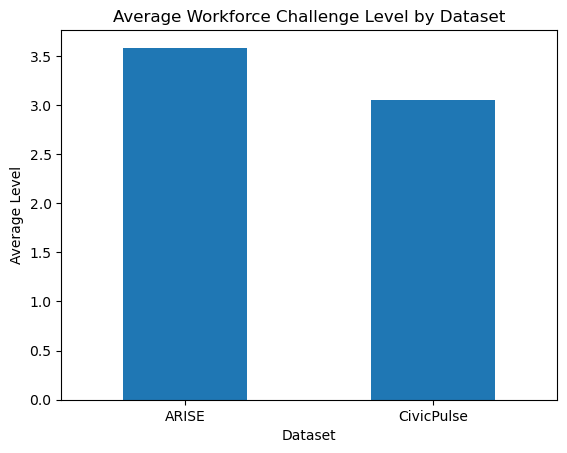

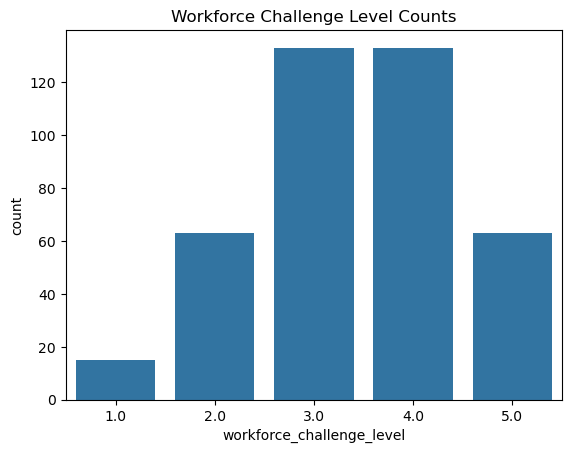

<Figure size 640x480 with 0 Axes>

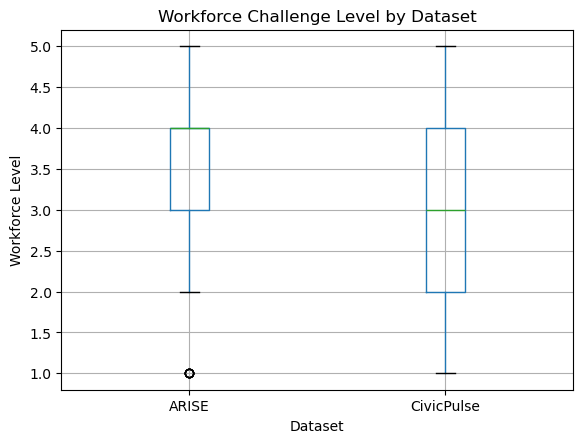

In [119]:
# Workforce Challenge Level

# Bar Chart (mean comparison)
plt.figure()
analysis_df.groupby("source")["workforce_challenge_level"].mean().plot(kind="bar")
plt.title("Average Workforce Challenge Level by Dataset")
plt.ylabel("Average Level")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.show()

#Count plot
sns.countplot(x="workforce_challenge_level", data=analysis_df)
plt.title("Workforce Challenge Level Counts")
plt.show()

# Boxplot
plt.figure()

analysis_df.boxplot(
    column="workforce_challenge_level",
    by="source"
)

plt.title("Workforce Challenge Level by Dataset")
plt.suptitle("")
plt.xlabel("Dataset")
plt.ylabel("Workforce Level")

plt.show()


ARISE reports slightly higher average workforce challenge levels compared to CivicPulse. The distribution shows that CivicPulse responses are more spread out, indicating greater variability. ARISE responses are more concentrated, with a few low-value outliers.

## Fiscal Condition Analysis

This section examines financial health across datasets using average values and distribution.

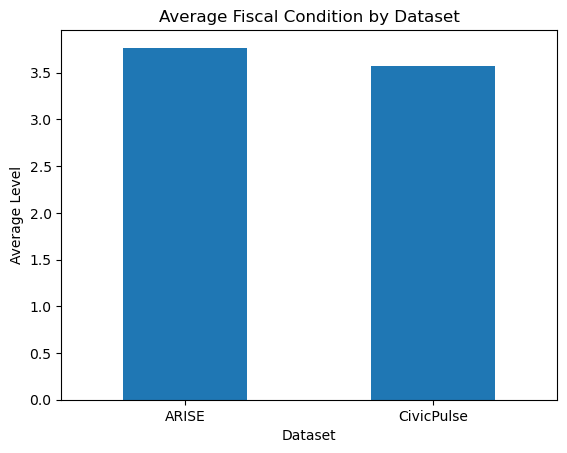

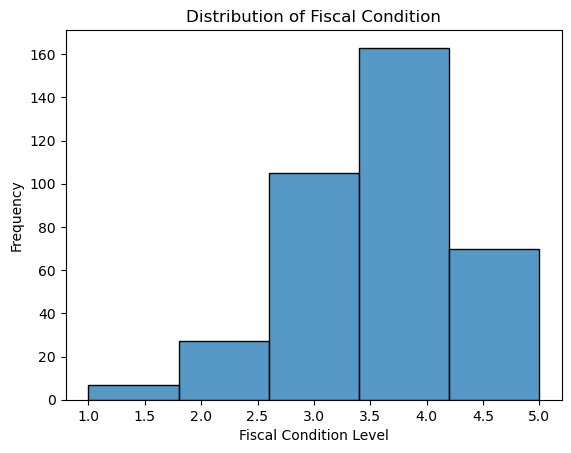

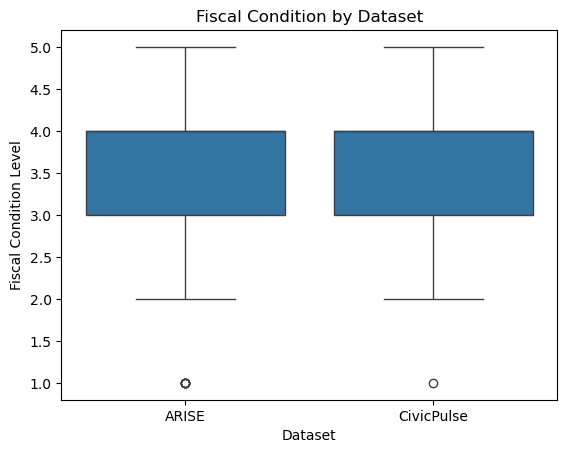

In [120]:
# Fiscal Condition Overall

# Bar Chart
plt.figure()
analysis_df.groupby("source")["fiscal_condition_overall"].mean().plot(kind="bar")
plt.title("Average Fiscal Condition by Dataset")
plt.ylabel("Average Level")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.show()

# Histogram
plt.figure()
sns.histplot(analysis_df["fiscal_condition_overall"], bins=5)
plt.title("Distribution of Fiscal Condition")
plt.xlabel("Fiscal Condition Level")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure()
sns.boxplot(x="source", y="fiscal_condition_overall", data=analysis_df)
plt.title("Fiscal Condition by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Fiscal Condition Level")
plt.show()

Both datasets show similar average fiscal condition levels. Most responses fall between levels 3 and 4, with similar spread across datasets. A few lower-value outliers are observed.

## Infrastructure Finance Stress Analysis

A composite index is created to measure infrastructure finance stress based on multiple financial constraint indicators.

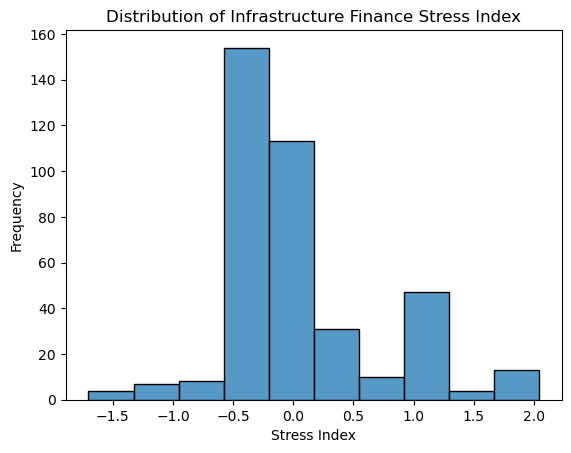

<Figure size 640x480 with 0 Axes>

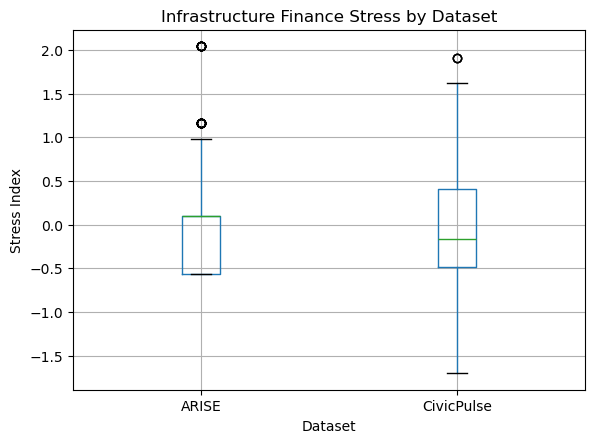

In [121]:
# Infrastructure Finance Stress Index

# Histogram
plt.figure()
sns.histplot(analysis_df["infra_finance_stress_index"], bins=10)
plt.title("Distribution of Infrastructure Finance Stress Index")
plt.xlabel("Stress Index")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure()

analysis_df.boxplot(
    column="infra_finance_stress_index",
    by="source"
)

plt.title("Infrastructure Finance Stress by Dataset")
plt.suptitle("")
plt.xlabel("Dataset")
plt.ylabel("Stress Index")

plt.show()

Infrastructure stress shows moderate variation across observations. CivicPulse responses exhibit slightly greater variability, suggesting differences in perceived financial stress.

## Governance Practice Index

This index combines multiple governance-related variables into a single measure.

It captures the extent to which formal processes, strategies, and performance practices are used by local governments.

The index provides an overall view of governance practices for analysis.

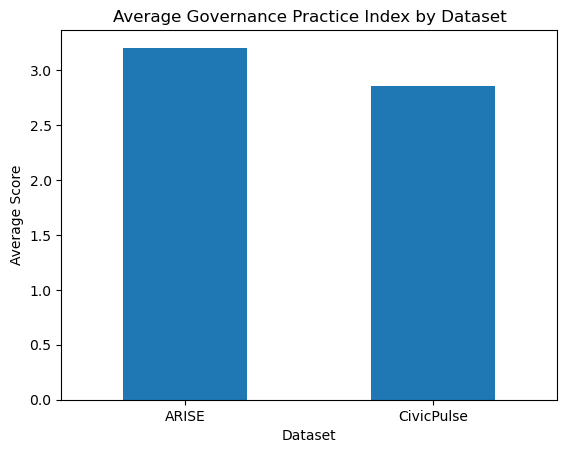

In [122]:
# Governance Practice Index

plt.figure()
analysis_df.groupby("source")["governance_practice_index"].mean().plot(kind="bar")
plt.title("Average Governance Practice Index by Dataset")
plt.ylabel("Average Score")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.show()

## Correlation Analysis

This section examines relationships between key variables such as workforce challenges, fiscal condition, and infrastructure stress.

In [123]:
#Correlation analysis


correlation_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall",
    "infra_finance_stress_index",
    "grant_capacity_score",
    "governance_practice_index"
]

correlation_matrix = analysis_df[correlation_vars].corr()

print("Correlation matrix:")
display(correlation_matrix.round(3))

Correlation matrix:


,workforce_challenge_level,fiscal_condition_overall,infra_finance_stress_index,grant_capacity_score,governance_practice_index
workforce_challenge_level,1.000,-0.195,0.024,-0.202,-0.130
fiscal_condition_overall,-0.195,1.000,-0.005,0.146,0.264
infra_finance_stress_index,0.024,-0.005,1.000,-0.011,-0.065
grant_capacity_score,-0.202,0.146,-0.011,1.000,0.118
governance_practice_index,-0.130,0.264,-0.065,0.118,1.000


Workforce challenges and fiscal condition show a weak negative relationship, while infrastructure stress shows little correlation with other variables.

In [124]:
#Cross-tabulation analysis
# Cross-tabs show count patterns between categorical/ordinal variables.

ct_workforce_fiscal = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"]
)

ct_workforce_source = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["source"]
)

analysis_df["infra_stress_group"] = pd.qcut(
    analysis_df["infra_finance_stress_index"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

ct_workforce_infra = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["infra_stress_group"]
)

print("Cross-tab: Workforce Challenge vs Fiscal Condition")
display(ct_workforce_fiscal)

print("Cross-tab: Workforce Challenge vs Dataset Source")
display(ct_workforce_source)

print("Cross-tab: Workforce Challenge vs Infrastructure Stress Group")
display(ct_workforce_infra)

Cross-tab: Workforce Challenge vs Fiscal Condition


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0
workforce_challenge_level,,,,,
1.0,0,1,5,3,5
2.0,0,1,11,33,14
3.0,0,9,35,47,28
4.0,3,11,36,58,15
5.0,4,5,18,21,8


Cross-tab: Workforce Challenge vs Dataset Source


source,ARISE,CivicPulse
workforce_challenge_level,,
1.0,6,9
2.0,32,31
3.0,85,48
4.0,97,36
5.0,53,10


Cross-tab: Workforce Challenge vs Infrastructure Stress Group


infra_stress_group,Low,Medium,High
workforce_challenge_level,,,
1.0,6,2,6
2.0,19,20,20
3.0,55,38,32
4.0,49,42,38
5.0,25,18,20


In [125]:
#Percentage cross-tabs
# Percentages make comparisons easier when group sizes are different.

ct_workforce_fiscal_pct = (
    pd.crosstab(
        analysis_df["workforce_challenge_level"],
        analysis_df["fiscal_condition_overall"],
        normalize="index"
    ) * 100
).round(1)

ct_workforce_infra_pct = (
    pd.crosstab(
        analysis_df["workforce_challenge_level"],
        analysis_df["infra_stress_group"],
        normalize="index"
    ) * 100
).round(1)

print("Percentage cross-tab: Workforce vs Fiscal Condition")
display(ct_workforce_fiscal_pct)

print("Percentage cross-tab: Workforce vs Infrastructure Stress")
display(ct_workforce_infra_pct)

Percentage cross-tab: Workforce vs Fiscal Condition


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0
workforce_challenge_level,,,,,
1.0,0.0,7.1,35.7,21.4,35.7
2.0,0.0,1.7,18.6,55.9,23.7
3.0,0.0,7.6,29.4,39.5,23.5
4.0,2.4,8.9,29.3,47.2,12.2
5.0,7.1,8.9,32.1,37.5,14.3


Percentage cross-tab: Workforce vs Infrastructure Stress


infra_stress_group,Low,Medium,High
workforce_challenge_level,,,
1.0,42.9,14.3,42.9
2.0,32.2,33.9,33.9
3.0,44.0,30.4,25.6
4.0,38.0,32.6,29.5
5.0,39.7,28.6,31.7


## Stacked Bar Charts

These charts show how workforce challenge levels are distributed across datasets and how fiscal condition varies across workforce levels.

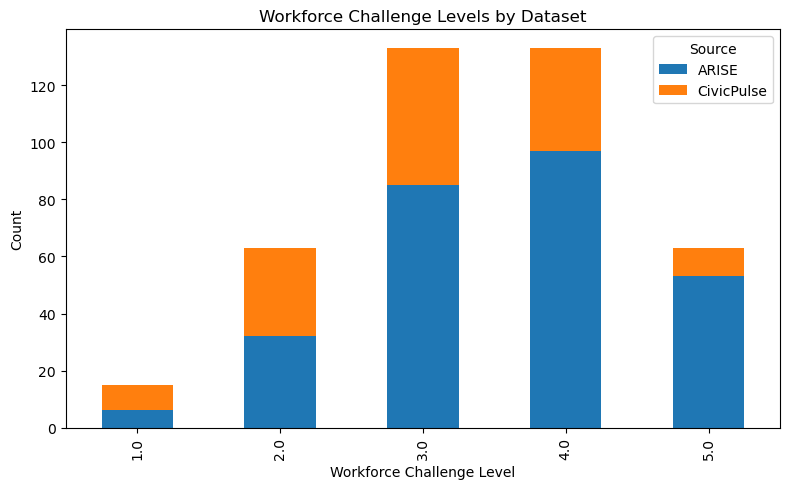

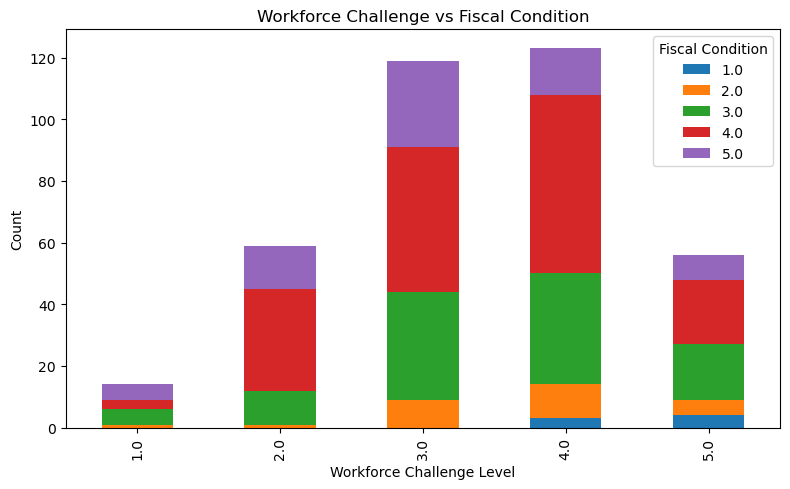

In [126]:
# Stacked bar charts


ct_workforce_source.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Workforce Challenge Levels by Dataset")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Count")
plt.legend(title="Source")
plt.tight_layout()
plt.show()

ct_workforce_fiscal.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Workforce Challenge vs Fiscal Condition")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Count")
plt.legend(title="Fiscal Condition")
plt.tight_layout()
plt.show()

Most responses in both datasets are concentrated at workforce challenge levels 3 and 4, indicating moderate workforce challenges.

ARISE has slightly higher counts at higher levels (4 and 5), suggesting somewhat greater workforce challenges compared to CivicPulse.

When comparing workforce challenge with fiscal condition, most observations fall within mid-level fiscal condition (levels 3 and 4).

Across all workforce levels, extreme fiscal conditions (very low or very high) are less common.

Overall, the results show that workforce challenges are generally associated with moderate fiscal conditions, with similar patterns across both datasets.

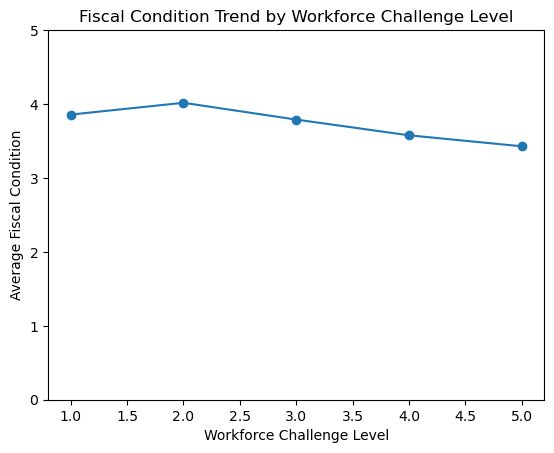

In [86]:
# Group data by workforce challenge level and compute average fiscal condition
# This helps us see how fiscal condition changes across different workforce levels
analysis_df.groupby("workforce_challenge_level")["fiscal_condition_overall"] \
    .mean() \
    .plot(marker='o')
# Line plot with markers to show trend clearly
plt.title("Fiscal Condition Trend by Workforce Challenge Level")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Average Fiscal Condition")

plt.ylim(0, 5)  

plt.show()


## Governance Analysis

This section analyzes governance practices and their relationship with workforce challenges and fiscal condition.

It compares governance practice levels across datasets and examines differences by government type and respondent role.

Governance practice index by source:


,mean,median,std,count
source,,,,
ARISE,3.204,3.0,0.979,270
CivicPulse,2.857,3.0,1.064,105


Government type summary:


workforce_challenge_level               \
                                              mean median count   
government_type                                                   
County                                       3.042    3.0    24   
Housing Special District                     2.667    3.0     3   
Municipality                                 3.071    3.0    98   
Water Special District                       3.000    3.0     9   

                         fiscal_condition_overall               \
                                             mean median count   
government_type                                                  
County                                      3.810    4.0    21   
Housing Special District                    3.000    3.0     2   
Municipality                                3.552    4.0    87   
Water Special District                      3.250    3.5     8   

                         governance_practice_index               
                                              mean median count  
government_type                                                  
County                                       3.531  3.583    16  
Housing Special District                     2.500  2.500     2  
Municipality                                 2.778  3.000    79  
Water Special District                       2.375  2.167     8

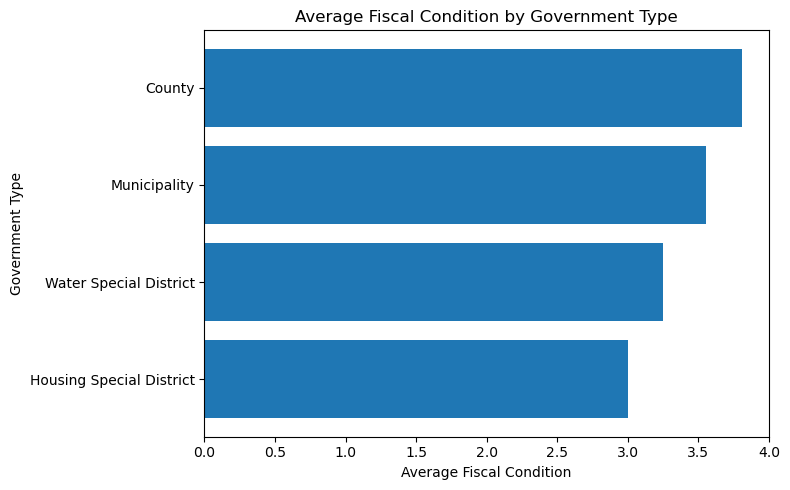

Respondent role summary:


workforce_challenge_level               \
                                                  mean median count   
respondent_role                                                       
Civil Service Leader                             3.155    3.0    58   
County/Municipal Policymaker                     2.974    3.0    76   

                             fiscal_condition_overall               
                                                 mean median count  
respondent_role                                                     
Civil Service Leader                            3.240    3.0    50  
County/Municipal Policymaker                    3.809    4.0    68

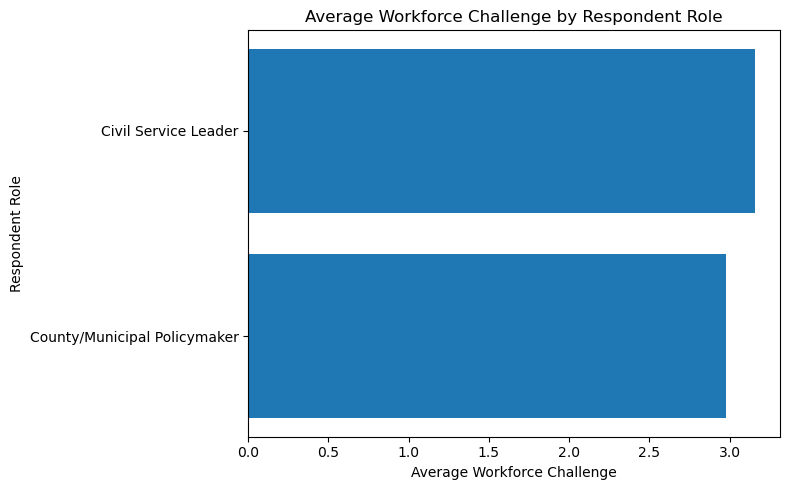

In [87]:
#Governance analysis


print("Governance practice index by source:")
display(analysis_df.groupby("source")["governance_practice_index"].agg(["mean", "median", "std", "count"]).round(3))

# Government type is only available for CivicPulse in the uploaded data.
gov_df = analysis_df.dropna(subset=["government_type"]).copy()

if not gov_df.empty:
    govtype_summary = gov_df.groupby("government_type")[
        ["workforce_challenge_level", "fiscal_condition_overall", "governance_practice_index"]
    ].agg(["mean", "median", "count"])

    print("Government type summary:")
    display(govtype_summary.round(3))

    gov_plot = gov_df.groupby("government_type")["fiscal_condition_overall"].mean().sort_values()

    plt.figure(figsize=(8, 5))
    plt.barh(gov_plot.index.astype(str), gov_plot.values)
    plt.title("Average Fiscal Condition by Government Type")
    plt.xlabel("Average Fiscal Condition")
    plt.ylabel("Government Type")
    plt.tight_layout()
    plt.show()

# Respondent role is only available for CivicPulse in the uploaded data.
role_df = analysis_df.dropna(subset=["respondent_role"]).copy()

if not role_df.empty:
    role_summary = role_df.groupby("respondent_role")[
        ["workforce_challenge_level", "fiscal_condition_overall"]
    ].agg(["mean", "median", "count"])

    print("Respondent role summary:")
    display(role_summary.round(3))

    role_plot = role_df.groupby("respondent_role")["workforce_challenge_level"].mean().sort_values()

    plt.figure(figsize=(8, 5))
    plt.barh(role_plot.index.astype(str), role_plot.values)
    plt.title("Average Workforce Challenge by Respondent Role")
    plt.xlabel("Average Workforce Challenge")
    plt.ylabel("Respondent Role")
    plt.tight_layout()
    plt.show()

The governance practice index is slightly higher on average in ARISE compared to CivicPulse, indicating somewhat stronger governance practices in the ARISE dataset.

Across government types, counties show the highest average fiscal condition and governance practice levels, followed by municipalities. Special districts tend to have slightly lower values.

From the respondent role analysis, civil service leaders report slightly higher workforce challenge levels compared to policymakers, while policymakers report higher fiscal condition levels.

Overall, governance practices vary moderately across groups, with consistent patterns in workforce challenges and fiscal condition.

## Grant Capacity Analysis

This section analyzes the ability of local governments to obtain or compete for external funding.

The grant capacity score is compared across datasets, and the distribution of grant-related challenges is examined for ARISE.

Grant capacity score by source:


,mean,median,std,count
source,,,,
ARISE,2.555,3.0,0.844,238
CivicPulse,3.602,4.0,1.178,118


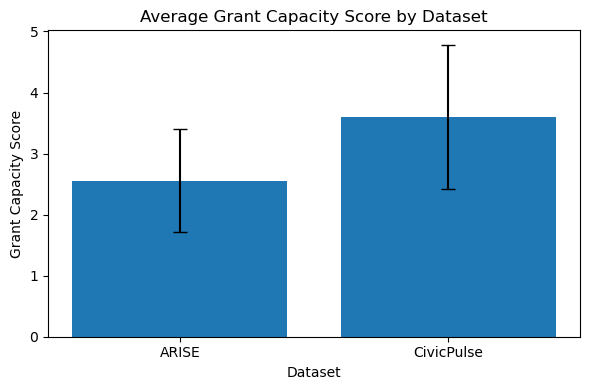

ARISE grant challenge count summary:


count    273.000000
mean       2.523810
std        1.437542
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: grant_challenge_count, dtype: float64

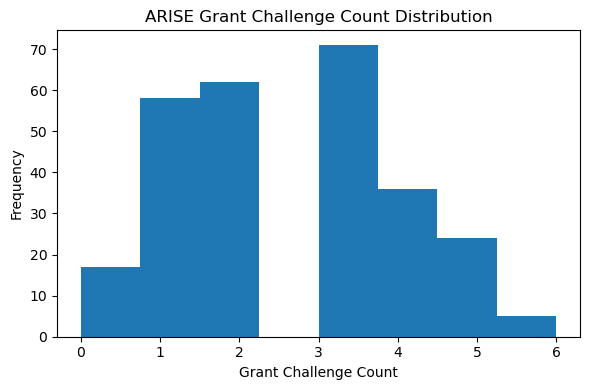

In [88]:
#Grant capacity analysis
# Higher grant_capacity_score means stronger grant/external funding capacity.

print("Grant capacity score by source:")
grant_summary = analysis_df.groupby("source")["grant_capacity_score"].agg(["mean", "median", "std", "count"])
display(grant_summary.round(3))

plt.figure(figsize=(6, 4))
plt.bar(grant_summary.index, grant_summary["mean"], yerr=grant_summary["std"], capsize=5)
plt.title("Average Grant Capacity Score by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Grant Capacity Score")
plt.tight_layout()
plt.show()

# ARISE-only grant challenge count
arise_grant = analysis_df[analysis_df["source"] == "ARISE"].copy()

print("ARISE grant challenge count summary:")
display(arise_grant["grant_challenge_count"].describe())

plt.figure(figsize=(6, 4))
arise_grant["grant_challenge_count"].dropna().plot(kind="hist", bins=8)
plt.title("ARISE Grant Challenge Count Distribution")
plt.xlabel("Grant Challenge Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

CivicPulse shows a higher average grant capacity score (mean ≈ 3.60) compared to ARISE (mean ≈ 2.56), indicating stronger perceived ability to compete for grants in CivicPulse.

The variability is also higher in CivicPulse, suggesting more variation in grant capacity across respondents.

For ARISE, the average number of grant challenges is around 2.24, with most responses falling between 1 and 3 challenges.

The distribution shows that while some jurisdictions face few challenges, others report multiple barriers to securing grants.

Overall, the results suggest moderate grant challenges in ARISE and relatively higher perceived grant capacity in CivicPulse.

## Interorganizational Relationship Analysis

This section examines collaboration and partnership challenges across organizations.

For ARISE, an interorganizational difficulty index is used to measure collaboration challenges.

For CivicPulse, a partnership indicator is used to compare workforce challenges and fiscal condition based on collaboration presence.

ARISE interorganizational difficulty index:


count    248.000000
mean       2.405914
std        0.953895
min        1.000000
25%        1.666667
50%        2.333333
75%        3.000000
max        5.000000
Name: interorg_difficulty_index, dtype: float64

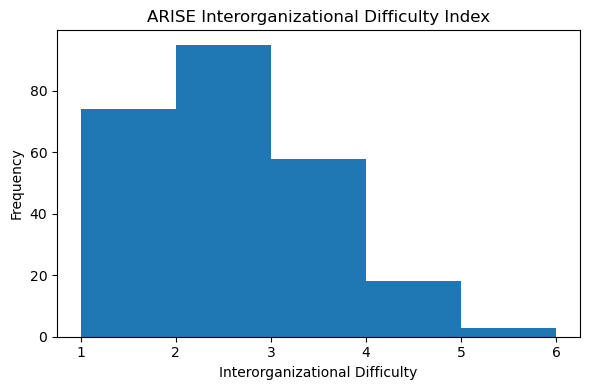

CivicPulse partner collaboration indicator:


interorg_partner_indicator
NaN    79
1.0    30
0.0    26
Name: count, dtype: int64

CivicPulse workforce/fiscal condition by partnership status:


workforce_challenge_level               \
                                           mean median count   
partnership_status                                             
With collaboration                        3.233    3.0    30   
Without collaboration                     3.038    3.0    26   

                      fiscal_condition_overall               
                                          mean median count  
partnership_status                                           
With collaboration                       3.433    4.0    30  
Without collaboration                    3.654    4.0    26

In [101]:
#Interorganizational relationship analysis
# This addresses the interorganizational relationships part of the project.


print("ARISE interorganizational difficulty index:")
arise_interorg = analysis_df[analysis_df["source"] == "ARISE"].copy()
display(arise_interorg["interorg_difficulty_index"].describe())

plt.figure(figsize=(6, 4))

arise_interorg["interorg_difficulty_index"].dropna().plot(
    kind="hist",
    bins=[1, 2, 3, 4, 5, 6]
)

plt.title("ARISE Interorganizational Difficulty Index")
plt.xlabel("Interorganizational Difficulty")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("CivicPulse partner collaboration indicator:")
civic_partner = analysis_df[analysis_df["source"] == "CivicPulse"].copy()
display(civic_partner["interorg_partner_indicator"].value_counts(dropna=False))

# Add readable labels for partnership status
civic_partner["partnership_status"] = civic_partner["interorg_partner_indicator"].map({
    0: "Without collaboration",
    1: "With collaboration"
})

# Summarize workforce and fiscal condition by partnership status
partner_summary = civic_partner.groupby("partnership_status")[
    ["workforce_challenge_level", "fiscal_condition_overall"]
].agg(["mean", "median", "count"])

print("CivicPulse workforce/fiscal condition by partnership status:")
display(partner_summary.round(3))

The ARISE interorganizational difficulty index has an average value of approximately 2.41, indicating moderate collaboration challenges among local governments.

The distribution shows most responses concentrated between levels 2 and 3, with fewer cases at extreme levels.

In CivicPulse, the partnership indicator shows that jurisdictions with collaboration (value = 1) have slightly higher workforce challenge levels (mean ≈ 3.23) compared to those without collaboration (mean ≈ 3.04).

However, jurisdictions without collaboration report slightly higher fiscal condition (mean ≈ 3.65) compared to those with collaboration (mean ≈ 3.43).

Overall, collaboration is associated with slightly higher workforce challenges, while fiscal condition differences remain moderate.

## Regression Analysis

This section examines how workforce challenges and infrastructure financial stress are associated with fiscal condition.

Separate regression models are estimated for ARISE and CivicPulse to identify dataset-specific patterns.

In [90]:
# Regression analysis by dataset

reg_df = analysis_df[
    [
        "source",
        "fiscal_condition_overall",
        "workforce_challenge_level",
        "infra_finance_stress_index"
    ]
].dropna()

# Helper function to run OLS regression
def run_ols(df, y_col, x_cols):
    X = df[x_cols].astype(float)
    X = sm.add_constant(X)
    y = df[y_col].astype(float)
    return sm.OLS(y, X).fit()

# Run regression for ARISE dataset
model_arise = run_ols(
    reg_df[reg_df["source"] == "ARISE"],
    "fiscal_condition_overall",
    ["workforce_challenge_level", "infra_finance_stress_index"]
)

# Run regression for CivicPulse dataset
model_civic = run_ols(
    reg_df[reg_df["source"] == "CivicPulse"],
    "fiscal_condition_overall",
    ["workforce_challenge_level", "infra_finance_stress_index"]
)

# Convert regression output into a clean table format
def regression_table(model, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "variable": model.params.index,
        "coefficient": model.params.values,
        "p_value": model.pvalues.values,
        "r_squared": model.rsquared
    })
# Combine ARISE and CivicPulse results
separate_regression_results = pd.concat([
    regression_table(model_arise, "ARISE"),
    regression_table(model_civic, "CivicPulse")
], ignore_index=True)

print("Separate regression results:")
display(separate_regression_results.round(4))

Separate regression results:


,dataset,variable,coefficient,p_value,r_squared
0,ARISE,const,4.0189,0.0000,0.0851
1,ARISE,workforce_challenge_level,-0.0667,0.2356,0.0851
2,ARISE,infra_finance_stress_index,-0.3396,0.0000,0.0851
3,CivicPulse,const,4.2509,0.0000,0.3706
4,CivicPulse,workforce_challenge_level,-0.2226,0.0016,0.3706
5,CivicPulse,infra_finance_stress_index,0.6098,0.0000,0.3706


For ARISE, infrastructure financial stress has a significant negative relationship with fiscal condition (coefficient ≈ -0.33), indicating that higher financial stress is associated with lower fiscal condition.

Workforce challenge level is not statistically significant in ARISE (p > 0.05), suggesting it does not strongly explain fiscal condition in this dataset.

For CivicPulse, both workforce challenge level and infrastructure financial stress are statistically significant.

Workforce challenge level has a negative relationship (coefficient ≈ -0.22), indicating that higher workforce challenges are associated with lower fiscal condition.

In contrast, infrastructure financial stress shows a positive relationship (coefficient ≈ 0.61), suggesting different measurement or perception patterns compared to ARISE.

The model fit is stronger for CivicPulse (R² ≈ 0.37) compared to ARISE (R² ≈ 0.08), indicating that the variables explain more variation in fiscal condition in CivicPulse.

## Combined Regression Analysis (With Source Control)

This model combines both ARISE and CivicPulse datasets into a single regression.

A source dummy variable is included to control for differences between datasets.

The model examines how workforce challenges and infrastructure financial stress relate to fiscal condition while accounting for dataset-specific effects.

In [91]:
#Combined regression with source control
# This combines both datasets and controls for dataset source.

# Create a copy of regression dataset
combined_reg_df = reg_df.copy()

# Create dummy variable for source (CivicPulse = 1, ARISE = 0)
source_dummy = pd.get_dummies(combined_reg_df["source"], drop_first=True)

# Combine independent variables with source dummy
X_combined = pd.concat(
    [
        combined_reg_df[["workforce_challenge_level", "infra_finance_stress_index"]],
        source_dummy
    ],
    axis=1
)

X_combined = X_combined.astype(float)
X_combined = sm.add_constant(X_combined)

# Define dependent variable
y_combined = combined_reg_df["fiscal_condition_overall"].astype(float)

# Fit OLS regression model
combined_model = sm.OLS(y_combined, X_combined).fit()

combined_regression_results = pd.DataFrame({
    "variable": combined_model.params.index,
    "coefficient": combined_model.params.values,
    "p_value": combined_model.pvalues.values
})

# Display regression coefficients
print("Combined regression results:")
display(combined_regression_results.round(4))

# Display model performance metrics
print("\nCombined model strength:")
print("R-squared:", round(combined_model.rsquared, 4))
print("Adjusted R-squared:", round(combined_model.rsquared_adj, 4))
print("F-statistic p-value:", combined_model.f_pvalue)

Combined regression results:


,variable,coefficient,p_value
0,const,4.4750,0.0000
1,workforce_challenge_level,-0.1994,0.0000
2,infra_finance_stress_index,0.0024,0.9709
3,CivicPulse,-0.2973,0.0039



Combined model strength:
R-squared: 0.0594
Adjusted R-squared: 0.0518
F-statistic p-value: 5.081444812831971e-05


In the combined model, workforce challenge level shows a significant negative relationship with fiscal condition (coefficient ≈ -0.20), indicating that higher workforce challenges are associated with lower fiscal condition.

Infrastructure financial stress is not statistically significant in the combined model (p ≈ 0.94), suggesting it does not have a consistent effect across datasets.

The CivicPulse dummy variable is negative and significant (coefficient ≈ -0.30), indicating that fiscal condition values differ between datasets even after controlling for other variables.

The model explains a small portion of variation in fiscal condition (R² ≈ 0.06), indicating that other factors not included in the model may also influence fiscal condition.

Overall, workforce challenges remain an important factor, while dataset differences play a significant role.

In [92]:
# Regression interpretation in simple language
# This converts the regression outputs into readable statements.

print("Separate Regression Interpretation\n")

for name, model in [("ARISE", model_arise), ("CivicPulse", model_civic)]:
    print(name)
    print("- Workforce challenge:",
          f"coef = {model.params['workforce_challenge_level']:.3f},",
          f"p = {model.pvalues['workforce_challenge_level']:.3f},",
          significance_label(model.pvalues['workforce_challenge_level']))
    print("- Infrastructure stress:",
          f"coef = {model.params['infra_finance_stress_index']:.3f},",
          f"p = {model.pvalues['infra_finance_stress_index']:.3f},",
          significance_label(model.pvalues['infra_finance_stress_index']))
    print("- R-squared:", round(model.rsquared, 3))
    print()

print("Combined Regression Interpretation\n")
for var in combined_model.params.index:
    print(var + ":",
          f"coef = {combined_model.params[var]:.3f},",
          f"p = {combined_model.pvalues[var]:.3f},",
          significance_label(combined_model.pvalues[var]))

print("Combined R-squared:", round(combined_model.rsquared, 3))

Separate Regression Interpretation

ARISE
- Workforce challenge: coef = -0.067, p = 0.236, not statistically significant
- Infrastructure stress: coef = -0.340, p = 0.000, statistically significant
- R-squared: 0.085

CivicPulse
- Workforce challenge: coef = -0.223, p = 0.002, statistically significant
- Infrastructure stress: coef = 0.610, p = 0.000, statistically significant
- R-squared: 0.371

Combined Regression Interpretation

const: coef = 4.475, p = 0.000, statistically significant
workforce_challenge_level: coef = -0.199, p = 0.000, statistically significant
infra_finance_stress_index: coef = 0.002, p = 0.971, not statistically significant
CivicPulse: coef = -0.297, p = 0.004, statistically significant
Combined R-squared: 0.059


## Spatial Analysis (County-Level Insights)

To extend the analysis, a spatial-ready dataset was constructed by attaching jurisdiction-level identifiers such as county FIPS codes.

Since detailed geographic identifiers are only available in the CivicPulse dataset, spatial analysis is conducted at the county level using CivicPulse data.

This allows us to examine how key indicators such as workforce challenges, fiscal condition, and infrastructure stress vary across counties.

Spatial-ready dataset shape: (408, 49)


C:\Users\ANUDEEPTHI\AppData\Local\Temp\ipykernel_23232\615810567.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  spatial_df = pd.concat([arise_spatial, civic_spatial], ignore_index=True)


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,equity_group_elderly_support,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,respondent_tenure_local_gov,respondent_education_level,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,grant_capacity_success,governance_support_level,governance_formal_process,governance_stakeholder_strategy,governance_performance_routine,interorg_lack_partner_obstacle,interorg_internal_resource_obstacle,interorg_shared_goals_obstacle,interorg_partner_collaboration,capital_assets_condition,hazard_mitigation_planning_extent,emergency_agency_planning_involvement,source,government_type,respondent_role,government_name,grant_capacity_score,grant_challenge_count,governance_practice_index,interorg_difficulty_index,interorg_partner_indicator,infra_finance_spending_gap_z,infra_finance_unstable_funding_z,infra_finance_budget_constraints_z,infra_finance_stress_index,infra_stress_group,jurisdiction_id,jurisdiction_name,county_name,county_fips,place_fips
0,3.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,0.0,0.0,1.0,3.0,3.0,NaN,NaN,NaN,3.0,2.0,2.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN,3.0,3.0,3.0,2.333333,NaN,-0.350720,-0.455195,1.102291,0.098792,Medium,NaN,NaN,NaN,<NA>,NaN
1,4.0,4.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,5.0,1.0,0.0,1.0,2.0,3.0,NaN,NaN,NaN,4.0,1.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN,2.0,1.0,3.0,3.000000,NaN,2.840833,-0.455195,1.102291,1.162643,High,NaN,NaN,NaN,<NA>,NaN
2,5.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,1.0,0.0,1.0,3.0,4.0,NaN,NaN,NaN,2.0,3.0,2.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN,3.0,2.0,4.0,2.333333,NaN,2.840833,-0.455195,1.102291,1.162643,High,NaN,NaN,NaN,<NA>,NaN
3,3.0,3.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,6.0,0.0,0.0,1.0,2.0,3.0,NaN,NaN,NaN,1.0,1.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN,2.0,2.0,3.0,2.000000,NaN,-0.350720,-0.455195,1.102291,0.098792,Medium,NaN,NaN,NaN,<NA>,NaN
4,3.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,6.0,1.0,1.0,1.0,3.0,4.0,NaN,NaN,NaN,3.0,4.0,4.0,NaN,NaN,NaN,NaN,ARISE,NaN,NaN,NaN,3.0,3.0,4.0,3.666667,NaN,2.840833,2.188812,1.102291,2.043978,High,NaN,NaN,NaN,<NA>,NaN


CivicPulse county-level spatial summary:


,county_fips,response_count,avg_workforce_challenge,avg_fiscal_condition,avg_infra_stress
0,20001,5,3.0,3.4,-0.43
1,20005,1,3.0,NaN,NaN
2,20011,1,2.0,NaN,NaN
3,20013,1,4.0,3.0,-0.18
4,20015,2,4.5,3.0,-0.78
5,20021,1,4.0,5.0,0.43
6,20027,2,2.0,4.0,0.39
7,20031,1,2.0,4.0,-0.18
8,20035,2,3.0,4.5,-0.18
9,20037,2,3.0,4.5,-0.05


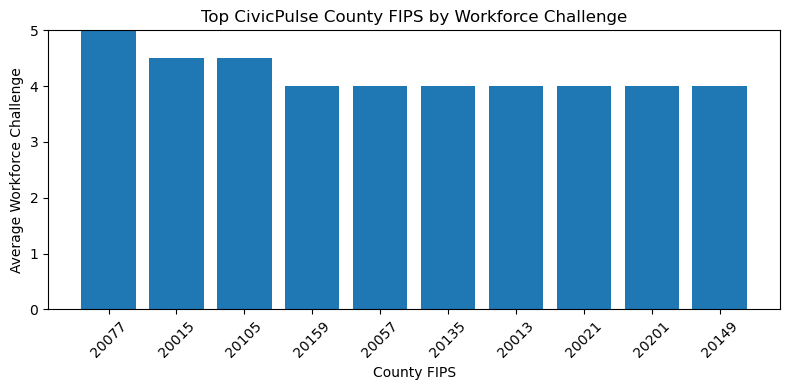

In [93]:
# OPTIONAL: SPATIAL / JURISDICTION-LEVEL ANALYSIS
# This section creates spatial-ready outputs without changing analysis_df.

# Helper function: find a column even if naming is slightly different
def find_column(df, possible_names):
    df_cols_lower = {col.lower(): col for col in df.columns}
    for name in possible_names:
        if name.lower() in df_cols_lower:
            return df_cols_lower[name.lower()]
    return None



# 1. Split final analysis dataset by source


arise_analysis = analysis_df[analysis_df["source"] == "ARISE"].reset_index(drop=True)
civic_analysis = analysis_df[analysis_df["source"] == "CivicPulse"].reset_index(drop=True)



# 2. Create ARISE location fields safely


arise_location = pd.DataFrame()

arise_fips_col = find_column(arise, ["fips", "FIPS"])
arise_place_col = find_column(arise, ["PLACENAME", "placename", "place_name"])
arise_county_col = find_column(arise, ["COUNTIES", "counties", "county"])

arise_location["jurisdiction_id"] = arise[arise_fips_col] if arise_fips_col else pd.NA
arise_location["jurisdiction_name"] = arise[arise_place_col] if arise_place_col else pd.NA
arise_location["county_name"] = arise[arise_county_col] if arise_county_col else pd.NA
arise_location["county_fips"] = pd.NA
arise_location["place_fips"] = pd.NA

# Match length with ARISE rows in analysis_df
arise_location = arise_location.reset_index(drop=True).head(len(arise_analysis))



# 3. Create CivicPulse location fields safely


civic_location = pd.DataFrame()

civic_county_fips_col = find_column(civic, ["stco_fips", "county_fips", "County_FIPS"])
civic_place_fips_col = find_column(civic, ["stpl_fips", "place_fips", "Place_FIPS"])
civic_name_col = find_column(civic, ["govname", "GovName", "government_name", "jurisdiction_name"])

civic_location["county_fips"] = civic[civic_county_fips_col] if civic_county_fips_col else pd.NA
civic_location["place_fips"] = civic[civic_place_fips_col] if civic_place_fips_col else pd.NA
civic_location["jurisdiction_name"] = civic[civic_name_col] if civic_name_col else pd.NA
civic_location["county_name"] = pd.NA
civic_location["jurisdiction_id"] = civic_location["place_fips"]

# Match length with CivicPulse rows in analysis_df
civic_location = civic_location.reset_index(drop=True).head(len(civic_analysis))



# 4. Attach location fields to analysis rows


arise_spatial = pd.concat(
    [arise_analysis.reset_index(drop=True), arise_location.reset_index(drop=True)],
    axis=1
)

civic_spatial = pd.concat(
    [civic_analysis.reset_index(drop=True), civic_location.reset_index(drop=True)],
    axis=1
)

# Combine into one spatial-ready dataset
spatial_df = pd.concat([arise_spatial, civic_spatial], ignore_index=True)

# Remove duplicate columns if any accidentally occur
spatial_df = spatial_df.loc[:, ~spatial_df.columns.duplicated()]

print("Spatial-ready dataset shape:", spatial_df.shape)
spatial_df["county_fips"] = spatial_df["county_fips"].astype("Int64")
display(spatial_df.head())



# 5. CivicPulse county-level spatial summary


civic_spatial_summary = (
    spatial_df[spatial_df["source"] == "CivicPulse"]
    .groupby("county_fips", dropna=False)
    .agg(
        response_count=("source", "count"),
        avg_workforce_challenge=("workforce_challenge_level", "mean"),
        avg_fiscal_condition=("fiscal_condition_overall", "mean"),
        avg_infra_stress=("infra_finance_stress_index", "mean")
    )
    .reset_index()
)

civic_spatial_summary = civic_spatial_summary.round(2)

print("CivicPulse county-level spatial summary:")
display(civic_spatial_summary.head(10))



# 6. Simple location-based visualization


top_workforce_counties = civic_spatial_summary.sort_values(
    by="avg_workforce_challenge",
    ascending=False
).head(10)

plt.figure(figsize=(8, 4))

plt.bar(
    top_workforce_counties["county_fips"].astype(str),
    top_workforce_counties["avg_workforce_challenge"]
)

plt.title("Top CivicPulse County FIPS by Workforce Challenge")
plt.xlabel("County FIPS")
plt.ylabel("Average Workforce Challenge")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
# Research questions and direct answers

corr_wf_fc = correlation_matrix.loc["workforce_challenge_level", "fiscal_condition_overall"]
corr_wf_infra = correlation_matrix.loc["workforce_challenge_level", "infra_finance_stress_index"]
corr_fc_infra = correlation_matrix.loc["fiscal_condition_overall", "infra_finance_stress_index"]

wf_arise = mean_comparison.loc["ARISE", "workforce_challenge_level"]
wf_civic = mean_comparison.loc["CivicPulse", "workforce_challenge_level"]

fc_arise = mean_comparison.loc["ARISE", "fiscal_condition_overall"]
fc_civic = mean_comparison.loc["CivicPulse", "fiscal_condition_overall"]

print("\nAnswers to Research Questions\n")

print("1. Workforce vs Fiscal Condition")
print(f"   Workforce and fiscal condition have a {corr_strength(corr_wf_fc)} relationship (r = {corr_wf_fc:.3f}).\n")

print("2. Workforce vs Infrastructure Stress")
print(f"   Workforce and infrastructure stress have a {corr_strength(corr_wf_infra)} relationship (r = {corr_wf_infra:.3f}).\n")

print("3. ARISE vs CivicPulse Comparison")
print(f"   ARISE workforce mean = {wf_arise:.3f}, CivicPulse workforce mean = {wf_civic:.3f}.")
print(f"   ARISE fiscal mean = {fc_arise:.3f}, CivicPulse fiscal mean = {fc_civic:.3f}.\n")

print("4. Grant Capacity")
print("   Grant capacity was included using ARISE grant success and CivicPulse grant competition effectiveness.")
print("   ARISE grant challenge count was also analyzed as ARISE-only context.\n")

print("5. Governance Practices")
print("   Governance was analyzed using elected official support in ARISE and planning/governance practice variables in CivicPulse.")
print("   Government type and respondent role were also analyzed where available.\n")

print("6. Interorganizational Relationships")
print("   ARISE collaboration obstacle variables and CivicPulse nonprofit partnership variables were analyzed as contextual measures.\n")

print("7. Regression Takeaway")
print("   Separate and combined regression models show that relationships differ across datasets, so interpretation should be cautious.")


Answers to Research Questions

1. Workforce vs Fiscal Condition
   Workforce and fiscal condition have a very weak relationship (r = -0.195).

2. Workforce vs Infrastructure Stress
   Workforce and infrastructure stress have a very weak relationship (r = 0.024).

3. ARISE vs CivicPulse Comparison
   ARISE workforce mean = 3.582, CivicPulse workforce mean = 3.052.
   ARISE fiscal mean = 3.768, CivicPulse fiscal mean = 3.568.

4. Grant Capacity
   Grant capacity was included using ARISE grant success and CivicPulse grant competition effectiveness.
   ARISE grant challenge count was also analyzed as ARISE-only context.

5. Governance Practices
   Governance was analyzed using elected official support in ARISE and planning/governance practice variables in CivicPulse.
   Government type and respondent role were also analyzed where available.

6. Interorganizational Relationships
   ARISE collaboration obstacle variables and CivicPulse nonprofit partnership variables were analyzed as contex

In [95]:
# Final insights table
# This table is useful for report, poster, and slides.

final_insights = pd.DataFrame({
    "No.": [1, 2, 3, 4, 5, 6, 7, 8],
    "Insight": [
        f"ARISE has higher average workforce challenges ({wf_arise:.3f}) than CivicPulse ({wf_civic:.3f}).",
        f"ARISE has slightly higher average fiscal condition ({fc_arise:.3f}) than CivicPulse ({fc_civic:.3f}).",
        f"Workforce challenge and fiscal condition show a {corr_strength(corr_wf_fc)} relationship (r = {corr_wf_fc:.3f}).",
        f"Workforce challenge and infrastructure stress show a {corr_strength(corr_wf_infra)} relationship (r = {corr_wf_infra:.3f}).",
        "Grant capacity was added using available grant-related variables from both datasets.",
        "Governance was added using available governance and respondent context variables.",
        "Interorganizational relationship analysis was added using ARISE collaboration obstacles and CivicPulse partnership information.",
        "Regression results suggest that relationships vary by dataset, so combined results should be interpreted carefully."
    ]
})
pd.set_option('display.max_colwidth', None)
display(final_insights)

,No.,Insight
0,1,ARISE has higher average workforce challenges (3.582) than CivicPulse (3.052).
1,2,ARISE has slightly higher average fiscal condition (3.768) than CivicPulse (3.568).
2,3,Workforce challenge and fiscal condition show a very weak relationship (r = -0.195).
3,4,Workforce challenge and infrastructure stress show a very weak relationship (r = 0.024).
4,5,Grant capacity was added using available grant-related variables from both datasets.
5,6,Governance was added using available governance and respondent context variables.
6,7,Interorganizational relationship analysis was added using ARISE collaboration obstacles and CivicPulse partnership information.
7,8,"Regression results suggest that relationships vary by dataset, so combined results should be interpreted carefully."


In [96]:
with pd.ExcelWriter("final_project_outputs.xlsx") as writer:
    
    analysis_df.to_excel(writer, sheet_name="Dataset", index=False)
    summary_stats.to_excel(writer, sheet_name="Summary_by_Source", index=False)
    correlation_matrix.to_excel(writer, sheet_name="Correlation")
    combined_regression_results.to_excel(writer, sheet_name="Regression", index=False)
    crosswalk_table.to_excel(writer, sheet_name="Crosswalk", index=False)
    harmonization_notes.to_excel(writer, sheet_name="Harmonization_Notes", index=False)
    final_insights.to_excel(writer, sheet_name="Insights", index=False)

    # Final harmonized variables
    final_common_vars[
        ["harmonized_variable", "arise_column", "civic_column"]
    ].to_excel(writer, sheet_name="Final_Harmonized_Variables", index=False)

    spatial_df.to_excel(writer, sheet_name="Spatial_Ready_Data", index=False)
    civic_spatial_summary.to_excel(writer, sheet_name="CivicPulse_Spatial_Summary", index=False)

print("All outputs saved in one Excel file.")

All outputs saved in one Excel file.
